In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 11, 
years: 2022, 


In [6]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv'

In [7]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,0,0


In [8]:
#Check months

dataset = dataset.query('month >= 6 & month <= 11')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.237090,-0.048711,-0.317377,0.048711,0.233606,-0.039714,-0.304677,0.039714,0.064241,0.055555,0.021262,0.055555,27.490000,38.045000,16.935000,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,27.661434,69.883681,634.525996,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,10,0
1,21.94079,40.97703,2010-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.610494,0.297777,-0.269769,-0.297777,0.589813,0.268988,-0.282681,-0.268988,0.054153,0.046797,0.051947,0.046797,19.087273,24.759091,13.415455,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,19.182475,53.285836,708.081877,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2010-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.158598,-0.002042,-0.195420,0.002042,0.161290,-0.000149,-0.195554,0.000149,0.079131,0.039658,0.030081,0.039658,26.500000,35.950000,17.050000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,60.840037,99.001511,625.519261,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,14,0
3,23.98253,40.91510,2010-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.600695,0.348246,-0.219345,-0.348246,0.564287,0.283836,-0.257383,-0.283836,0.049732,0.050856,0.027357,0.050856,24.495000,30.690000,18.300000,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,29.119374,48.335329,661.806941,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,40,0
4,23.69108,40.49593,2010-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.517065,0.247244,-0.249138,-0.247244,0.548352,0.286086,-0.228926,-0.286086,0.042899,0.042628,0.027381,0.042628,19.367500,24.000000,14.735000,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,27.828753,56.447650,608.274993,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5763,22.14670,40.82294,2021-08-16,κεντρικης μακεδονιας,σκυδρας,16,8,33,2021,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,239.5,18080.0,84.3,46.44339,0.445122,0.014416,-0.427180,-0.014416,0.443690,0.017735,-0.421358,-0.017735,0.118285,0.115395,0.067481,0.115395,30.280000,37.640000,22.920000,8.027348,-1.694000,16.188258,3.720184,18.65

In [10]:
dataset2 = read_data(path2, exclude_years = years_to_remove)
dataset2.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2022-01-01,κεντρικης μακεδονιας,αλεξανδρειας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.450000,8.126419,-1.340303,16.216012,1.011667,18.020179,1.565813,32.641755,8.896456,0.113685,0.113685,0.113685,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,26,0,0
1,21.94079,40.97703,2022-01-01,κεντρικης μακεδονιας,αλμωπιας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.810778,12.236000,7.385556,5.156188,-0.429920,9.002046,1.203846,8.268402,0.655058,20.890796,6.749332,2.557299,2.557299,2.557299,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0
2,22.89198,40.65603,2022-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.770000,8.206667,1.223333,14.106000,3.702000,17.271538,2.883846,26.801250,9.896667,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,26,0,0
3,23.98253,40.91510,2022-01-01,κεντρικης μακεδονιας,αμφιπολης,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.935000,5.506350,-0.849211,10.168715,1.184231,13.528745,0.333718,22.552471,8.162000,0.417504,0.417504,0.417504,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,79,20,79.0,20,79,9,9,4,1,1,2,0,26,0,0
4,23.69108,40.49593,2022-01-01,κεντρικης μακεδονιας,αριστοτελη,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,747.0,16994.0,24.5,46.91682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.014583,9.186667,6.842500,5.626176,0.027273,8.827055,1.857362,12.089767,0.979534,20.756913,8.392523,0.000000,0.000000,0.000000,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,0,0


In [11]:
#Check months

dataset2 = dataset2.query('month >= 6 & month <= 11')
dataset2.reset_index(inplace=True, drop=True)

In [12]:
dataset2

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2022-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.203561,0.003898,-0.207792,-0.003898,0.192471,-0.005826,-0.202880,0.005826,0.044951,0.038408,0.034214,0.038408,29.272500,38.310000,20.235000,8.126419,-1.340303,16.216012,1.011667,18.020179,1.565813,32.641755,8.896456,7.430859,60.492267,339.782435,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.000000,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,26,52,0
1,21.94079,40.97703,2022-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.619276,0.251041,-0.511561,-0.251041,0.621279,0.252002,-0.514743,-0.252002,0.051984,0.044962,0.040620,0.044962,20.111818,23.310000,16.913636,5.156188,-0.429920,9.002046,1.203846,8.268402,0.655058,20.890796,6.749332,32.516852,41.760239,468.251021,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.000000,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2022-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.098917,-0.022971,-0.126924,0.022971,0.130002,-0.019382,-0.158113,0.019382,0.048773,0.022557,0.040199,0.022557,29.500000,36.550000,22.450000,8.206667,1.223333,14.106000,3.702000,17.271538,2.883846,26.801250,9.896667,2.566023,60.273106,469.045192,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.000000,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,26,52,0
3,23.98253,40.91510,2022-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.476810,0.181223,-0.427585,-0.181223,0.475048,0.176300,-0.423468,-0.176300,0.061094,0.069950,0.033972,0.069950,23.105000,28.415000,17.795000,5.506350,-0.849211,10.168715,1.184231,13.528745,0.333718,22.552471,8.162000,135.776673,137.128588,490.154914,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.000000,116.778232,22,79,20,79.0,20,79,9,9,4,1,1,2,0,26,52,0
4,23.69108,40.49593,2022-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2022,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.692618,0.339332,-0.580010,-0.339332,0.681440,0.327785,-0.573466,-0.327785,0.040490,0.045362,0.027481,0.045362,21.703750,26.225000,17.182500,5.626176,0.027273,8.827055,1.857362,12.089767,0.979534,20.756913,8.392523,7.843521,9.150648,585.233898,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.000000,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,22.48398,40.64468,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,478.8,38293.0,86.8,46.44911,0.694571,0.353325,-0.589602,-0.353325,0.685882,0.343081,-0.584848,-0.343081,0.043877,0.051278,0.035686,0.051278,25.332500,31.340000,19.325000,8.126419,-1

In [13]:
dataset['lau1'].unique().shape

(38,)

In [14]:
dataset2['lau1'].unique().shape

(38,)

In [15]:
dataset = pd.concat([dataset, dataset2], axis=0)

In [16]:
dataset.reset_index(drop=True, inplace=True)

In [17]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-06-01,κεντρικης μακεδονιας,αλεξανδρειας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.237090,-0.048711,-0.317377,0.048711,0.233606,-0.039714,-0.304677,0.039714,0.064241,0.055555,0.021262,0.055555,27.490000,38.045000,16.935000,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,27.661434,69.883681,634.525996,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.000000,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,5,10,0
1,21.94079,40.97703,2010-06-01,κεντρικης μακεδονιας,αλμωπιας,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.610494,0.297777,-0.269769,-0.297777,0.589813,0.268988,-0.282681,-0.268988,0.054153,0.046797,0.051947,0.046797,19.087273,24.759091,13.415455,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,19.182475,53.285836,708.081877,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.000000,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,1,2,0
2,22.89198,40.65603,2010-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.158598,-0.002042,-0.195420,0.002042,0.161290,-0.000149,-0.195554,0.000149,0.079131,0.039658,0.030081,0.039658,26.500000,35.950000,17.050000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,60.840037,99.001511,625.519261,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.000000,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,7,14,0
3,23.98253,40.91510,2010-06-01,κεντρικης μακεδονιας,αμφιπολης,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.600695,0.348246,-0.219345,-0.348246,0.564287,0.283836,-0.257383,-0.283836,0.049732,0.050856,0.027357,0.050856,24.495000,30.690000,18.300000,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,29.119374,48.335329,661.806941,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.000000,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,20,40,0
4,23.69108,40.49593,2010-06-01,κεντρικης μακεδονιας,αριστοτελη,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.517065,0.247244,-0.249138,-0.247244,0.548352,0.286086,-0.228926,-0.286086,0.042899,0.042628,0.027381,0.042628,19.367500,24.000000,14.735000,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,27.828753,56.447650,608.274993,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.000000,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6261,22.48398,40.64468,2022-08-16,κεντρικης μακεδονιας,αλεξανδρειας,16,8,33,2022,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,478.8,38293.0,86.8,46.44911,0.694571,0.353325,-0.589602,-0.353325,0.685882,0.343081,-0.584848,-0.343081,0.043877,0.051278,0.035686,0.051278,25.332500,31.340000,19.325000,8.126419,-1.3

In [18]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,367,250,617,9.85%
1,2011,432,31,463,7.39%
2,2012,437,20,457,7.29%
3,2013,439,21,460,7.34%
4,2014,456,0,456,7.28%
5,2015,456,0,456,7.28%
6,2016,456,0,456,7.28%
7,2017,456,0,456,7.28%
8,2018,387,117,504,8.04%
9,2019,420,53,473,7.55%


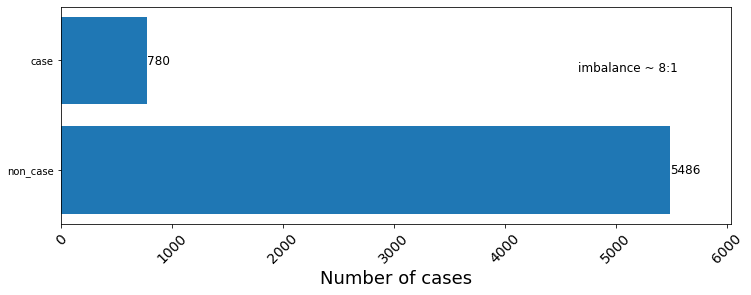

In [19]:
plot_imbalance(dataset)

In [20]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [21]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:4 || ##
Year: 2011 || w0:1, w1:3 || ##
Year: 2012 || w0:1, w1:3 || ##
Year: 2013 || w0:1, w1:3 || ##
Year: 2014 || w0:1, w1:3 || ##
Year: 2015 || w0:1, w1:3 || ##
Year: 2016 || w0:1, w1:3 || ##
Year: 2017 || w0:1, w1:3 || ##
Year: 2018 || w0:1, w1:3 || ##
Year: 2019 || w0:1, w1:3 || ##
Year: 2020 || w0:1, w1:3 || ##
Year: 2021 || w0:1, w1:3 || ##
Year: 2022 || w0:1, w1:4 || ##


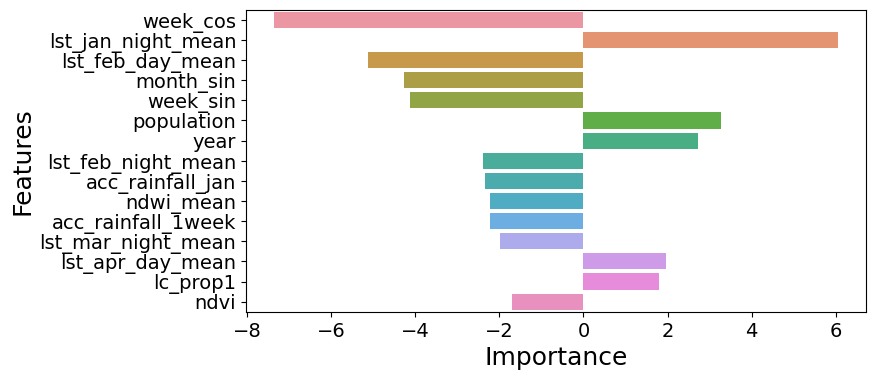

In [22]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

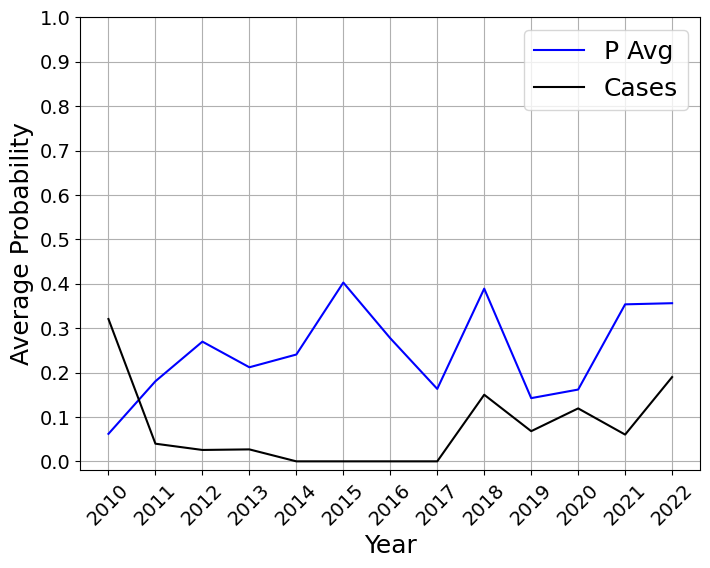

In [23]:
plot_trend_curve(results_test, list(dsc['case']))

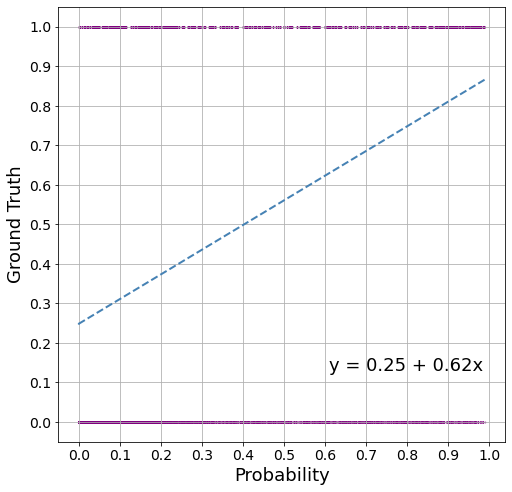

In [24]:
plot_probability_curve(results_test)

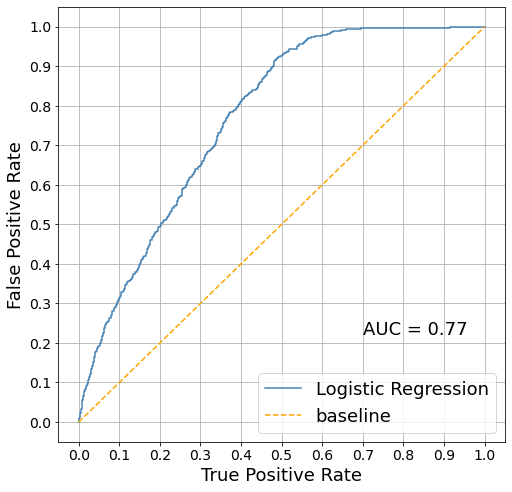

In [25]:
plot_roc_curve(results_test)

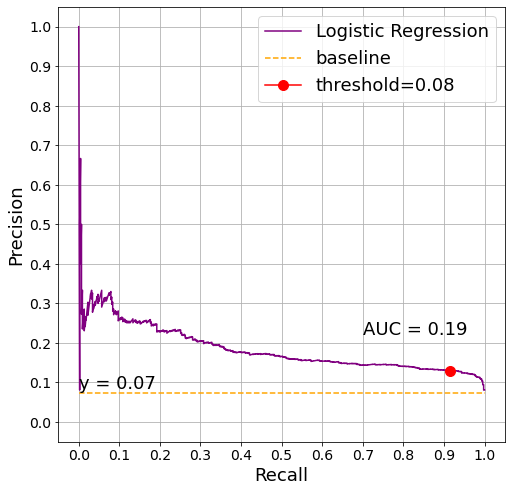

In [26]:
plot_pr_curve(results_test, plot_fbeta=True)

In [27]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 5, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 36.80%
Weighted Average: 43.75%


In [28]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/06/2010,0,0,0,NaN,NaN
1,16/06/2010,0,0,0,NaN,NaN
2,01/07/2010,1,0,1,0.00 %,0.0
3,16/07/2010,12,4,5,80.00 %,0.8
4,01/08/2010,23,5,5,100.00 %,1.0
...,...,...,...,...,...,...
151,16/09/2022,22,4,5,80.00 %,0.8
152,01/10/2022,11,2,5,40.00 %,0.4
153,16/10/2022,2,0,2,0.00 %,0.0
154,01/11/2022,0,0,0,NaN,NaN


In [29]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,89,19,26,73.08 %,0.7308
1,2011,24,7,20,35.00 %,0.3500
2,2012,19,3,19,15.79 %,0.1579
3,2013,17,3,17,17.65 %,0.1765
4,2014,0,0,0,nan %,NaN
5,2015,0,0,0,nan %,NaN
6,2016,0,0,0,nan %,NaN
7,2017,0,0,0,nan %,NaN
8,2018,69,13,34,38.24 %,0.3824
9,2019,36,5,24,20.83 %,0.2083


In [30]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.1, beta = 4)

In [31]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,89.0,0.1952,0.7836,0.6517,0.6517,0.6517,0.4247
1,2011,24.0,0.4298,0.7789,0.1173,0.9583,0.6741,0.2630
2,2012,19.0,0.5175,0.7243,0.0763,0.9474,0.5667,0.5096
3,2013,17.0,0.4693,0.7451,0.0748,0.9412,0.5597,0.3223
4,2014,0.0,0.5088,0.4912,0.0000,0.0000,0.0000,0.3845
5,2015,0.0,0.6250,0.3750,0.0000,0.0000,0.0000,0.8707
6,2016,0.0,0.5504,0.4496,0.0000,0.0000,0.0000,0.4631
7,2017,0.0,0.4057,0.5943,0.0000,0.0000,0.0000,0.2399
8,2018,69.0,0.6250,0.7124,0.2386,0.9855,0.8323,0.6054
9,2019,36.0,0.3706,0.7512,0.1775,0.8333,0.6846,0.2925


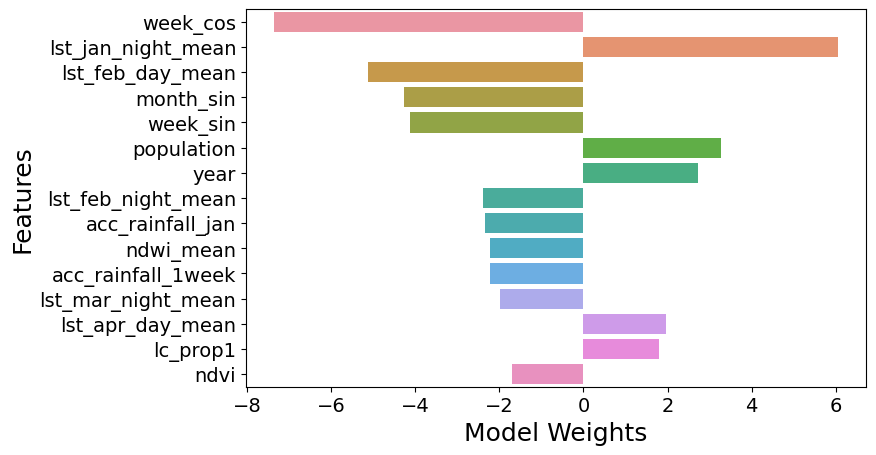

In [32]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))

In [33]:
results_test[results_test['year'] == 2022].head(30)

,x,y,municipality,day,month,year,case,probability
20,22.15177,40.44520,βεροιας,1,8,2022,1,0.976077
25,22.33660,40.28529,κατερινης,1,8,2022,0,0.973103
27,22.14670,40.82294,σκυδρας,1,8,2022,0,0.972967
29,22.95369,40.62334,θεσσαλονικης,16,8,2022,1,0.972505
37,22.15177,40.44520,βεροιας,16,8,2022,1,0.968612
40,23.55924,40.87800,βισαλτιας,1,8,2022,0,0.967466
41,22.33660,40.28529,κατερινης,16,8,2022,1,0.967345
45,22.85103,41.02728,κιλκις,1,8,2022,1,0.966044
46,21.99418,40.63248,ναουσας,1,8,2022,0,0.965572
58,22.41285,40.81412,πελλας,1,8,2022,1,0.962461
